# ✍️ Handwritten Character Recognition
**CodeAlpha ML Internship — Task 3**

- Loads MNIST (digits 0–9) and EMNIST Letters (A–Z) from local `data/` folder
- Trains CNN models with data augmentation
- Evaluates with Accuracy, Precision/Recall/F1, ROC-AUC, Confusion Matrix
- Saves models as `.keras` files for the Streamlit dashboard

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gzip, os, struct

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings('ignore')

DATA_DIR = './data'  # folder containing mnist.npz and emnist-letters-*.gz

print(f'TensorFlow: {tf.__version__}')
print(f'Data folder: {os.path.abspath(DATA_DIR)}')
print(f'Files found: {os.listdir(DATA_DIR)}')

TensorFlow: 2.21.0
Data folder: d:\CodeAlpha Internship\Handwritten Character Recognition\data
Files found: ['emnist-balanced-mapping.txt', 'emnist-balanced-test-images-idx3-ubyte.gz', 'emnist-balanced-test-labels-idx1-ubyte.gz', 'emnist-balanced-train-images-idx3-ubyte.gz', 'emnist-balanced-train-labels-idx1-ubyte.gz', 'emnist-byclass-mapping.txt', 'emnist-byclass-test-images-idx3-ubyte.gz', 'emnist-byclass-test-labels-idx1-ubyte.gz', 'emnist-byclass-train-images-idx3-ubyte.gz', 'emnist-byclass-train-labels-idx1-ubyte.gz', 'emnist-bymerge-mapping.txt', 'emnist-bymerge-test-images-idx3-ubyte.gz', 'emnist-bymerge-test-labels-idx1-ubyte.gz', 'emnist-bymerge-train-images-idx3-ubyte.gz', 'emnist-bymerge-train-labels-idx1-ubyte.gz', 'emnist-digits-mapping.txt', 'emnist-digits-test-images-idx3-ubyte.gz', 'emnist-digits-test-labels-idx1-ubyte.gz', 'emnist-digits-train-images-idx3-ubyte.gz', 'emnist-digits-train-labels-idx1-ubyte.gz', 'emnist-letters-mapping.txt', 'emnist-letters-test-images-i

## 1. Load MNIST (Digits 0–9)

MNIST Train: (60000, 28, 28, 1) | Test: (10000, 28, 28, 1)


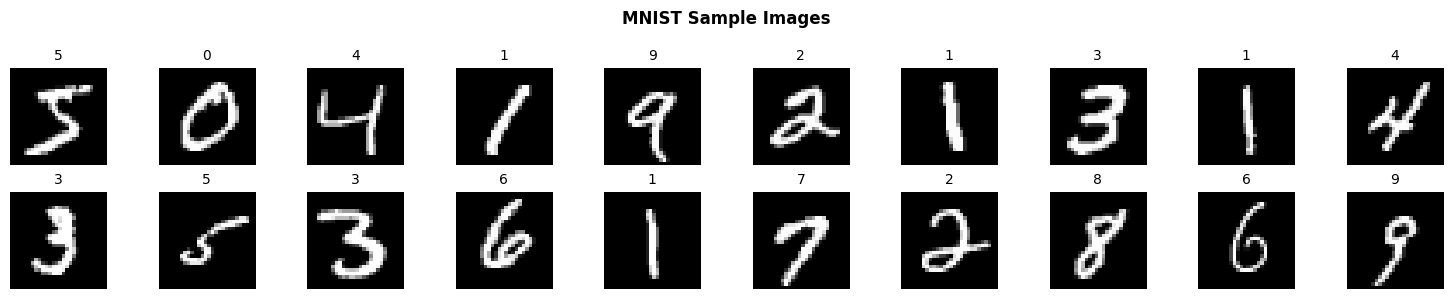

In [2]:
with np.load(os.path.join(DATA_DIR, 'mnist.npz')) as f:
    X_train_m, y_train_m = f['x_train'], f['y_train']
    X_test_m,  y_test_m  = f['x_test'],  f['y_test']

X_train_m = X_train_m.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test_m  = X_test_m.reshape(-1,  28, 28, 1).astype('float32') / 255.0
y_train_m_cat = to_categorical(y_train_m, 10)
y_test_m_cat  = to_categorical(y_test_m,  10)

print(f'MNIST Train: {X_train_m.shape} | Test: {X_test_m.shape}')

# Preview
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_train_m[i].squeeze(), cmap='gray')
    ax.set_title(str(y_train_m[i]), fontsize=10)
    ax.axis('off')
plt.suptitle('MNIST Sample Images', fontweight='bold')
plt.tight_layout(); plt.show()

## 2. Load EMNIST Letters (A–Z)

Loading EMNIST Letters from local files...
EMNIST Train: (124800, 28, 28, 1) | Test: (20800, 28, 28, 1)


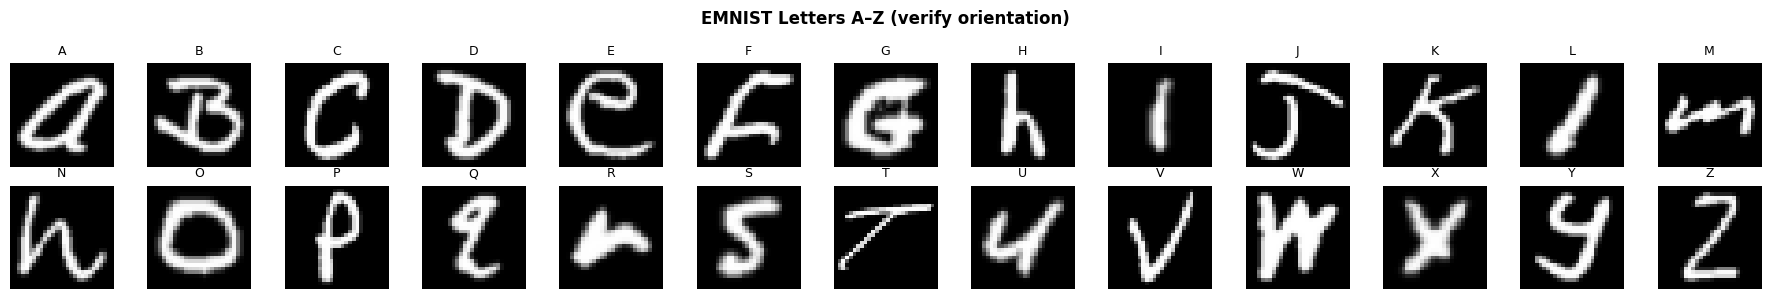

In [3]:
def read_idx_images(gz_path):
    with gzip.open(gz_path, 'rb') as f:
        magic, n, rows, cols = struct.unpack('>IIII', f.read(16))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows, cols)

def read_idx_labels(gz_path):
    with gzip.open(gz_path, 'rb') as f:
        magic, n = struct.unpack('>II', f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)

print('Loading EMNIST Letters from local files...')
X_train_e = read_idx_images(os.path.join(DATA_DIR, 'emnist-letters-train-images-idx3-ubyte.gz'))
y_train_e = read_idx_labels(os.path.join(DATA_DIR, 'emnist-letters-train-labels-idx1-ubyte.gz'))
X_test_e  = read_idx_images(os.path.join(DATA_DIR, 'emnist-letters-test-images-idx3-ubyte.gz'))
y_test_e  = read_idx_labels(os.path.join(DATA_DIR, 'emnist-letters-test-labels-idx1-ubyte.gz'))

# Fix EMNIST: images are transposed, labels are 1-26
X_train_e = np.transpose(X_train_e, (0, 2, 1))
X_test_e  = np.transpose(X_test_e,  (0, 2, 1))
y_train_e = y_train_e - 1
y_test_e  = y_test_e  - 1

X_train_e = X_train_e.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test_e  = X_test_e.reshape(-1,  28, 28, 1).astype('float32') / 255.0
y_train_e_cat = to_categorical(y_train_e, 26)
y_test_e_cat  = to_categorical(y_test_e,  26)

LETTERS = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
print(f'EMNIST Train: {X_train_e.shape} | Test: {X_test_e.shape}')

# Preview — verify letters look correct
fig, axes = plt.subplots(2, 13, figsize=(18, 3))
for i in range(26):
    idx = np.where(y_train_e == i)[0][0]
    ax  = axes[i // 13, i % 13]
    ax.imshow(X_train_e[idx].squeeze(), cmap='gray')
    ax.set_title(LETTERS[i], fontsize=9)
    ax.axis('off')
plt.suptitle('EMNIST Letters A–Z (verify orientation)', fontweight='bold')
plt.tight_layout(); plt.show()

## 3. CNN Architecture

In [4]:
def build_cnn(num_classes, deeper=False):
    """Build CNN. Use deeper=True for EMNIST (26 classes)."""
    inp = layers.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    if deeper:
        x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(512 if deeper else 256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    if deeper:
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## 4. Train MNIST Model

In [5]:
mnist_model = build_cnn(num_classes=10, deeper=False)
mnist_model.summary()

cb_mnist = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

mnist_history = mnist_model.fit(
    X_train_m, y_train_m_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    callbacks=cb_mnist,
    verbose=1
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,042 (3.33 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 70s 158ms/step - accuracy: 0.9395 - loss: 0.1991 - val_accuracy: 0.4728 - val_loss: 1.3804 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 67s 157ms/step - accuracy: 0.9789 - loss: 0.0674 - val_accuracy: 0.9885 - val_loss: 0.0368 - learning_rate: 0.0010
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 59s 140ms/step - accuracy: 0.9838 - loss: 0.0511 - val_accuracy: 0.9903 - val_loss: 0.0286 - learning_rate: 0.0010
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 56s 133ms/step - accuracy: 0.9875 - loss: 0.0415 - val_accuracy: 0.9932 - val_loss: 0.0295 - learning_rate: 0.0010
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 60s 142ms/step - accuracy: 0.9883 - loss: 0.0362 - val_accuracy: 0.9927 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 57s 135ms/step - accuracy: 0.9892 - loss: 0.0326 - val_accuracy: 0.9913 - val_loss: 0.0275 - learning_rate: 0.0010
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 59s 139ms/step - accuracy: 0.9

## 5. Train EMNIST Model (with Augmentation)

In [6]:
# Data augmentation — helps EMNIST generalize across handwriting styles
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(X_train_e)

emnist_model = build_cnn(num_classes=26, deeper=True)
emnist_model.summary()

cb_emnist = [
    callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy'),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1, min_lr=1e-6),
    callbacks.ModelCheckpoint('emnist_cnn_best.keras', save_best_only=True, monitor='val_accuracy')
]

emnist_history = emnist_model.fit(
    datagen.flow(X_train_e, y_train_e_cat, batch_size=256),
    steps_per_epoch=len(X_train_e) // 256,
    validation_data=(X_test_e, y_test_e_cat),
    epochs=40,
    callbacks=cb_emnist,
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,491,578 (13.32 MB)

 Trainable params: 3,490,106 (13.31 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 222s 449ms/step - accuracy: 0.7346 - loss: 0.8763 - val_accuracy: 0.5240 - val_loss: 1.6485 - learning_rate: 0.0010
Epoch 2/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8516 - loss: 0.4330 - val_accuracy: 0.5341 - val_loss: 1.6013 - learning_rate: 0.0010
Epoch 3/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 205s 421ms/step - accuracy: 0.8821 - loss: 0.3590 - val_accuracy: 0.9301 - val_loss: 0.2092 - learning_rate: 0.0010
Epoch 4/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8945 - loss: 0.3699 - val_accuracy: 0.9315 - val_loss: 0.2047 - learning_rate: 0.0010
Epoch 5/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 209s 429ms/step - accuracy: 0.9015 - loss: 0.2957 - val_accuracy: 0.9394 - val_loss: 0.1828 - learning_rate: 0.0010
Epoch 6/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9102 - loss: 0.2548 - val_accuracy: 0.9398 - val_loss: 0.1829 - learning_rate: 0.0010
Epoch 7/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 202s 415ms/step - accuracy: 0.91

## 6. Training Curves

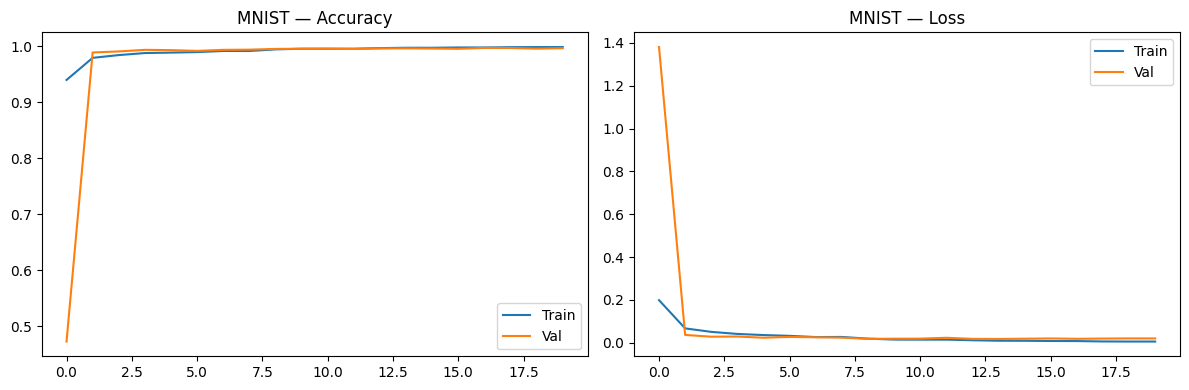

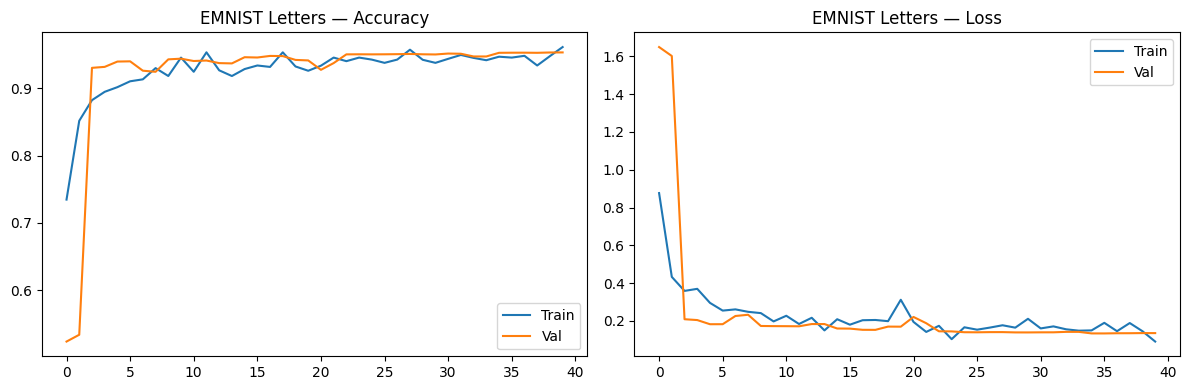

In [7]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'],     label='Train')
    ax1.plot(history.history['val_accuracy'], label='Val')
    ax1.set_title(f'{title} — Accuracy'); ax1.legend()
    ax2.plot(history.history['loss'],     label='Train')
    ax2.plot(history.history['val_loss'], label='Val')
    ax2.set_title(f'{title} — Loss'); ax2.legend()
    plt.tight_layout(); plt.show()

plot_history(mnist_history,  'MNIST')
plot_history(emnist_history, 'EMNIST Letters')

## 7. Evaluation


MNIST — Test Accuracy: 0.9951 | Loss: 0.0141

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       1.00      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

ROC-AUC (macro): 1.0000



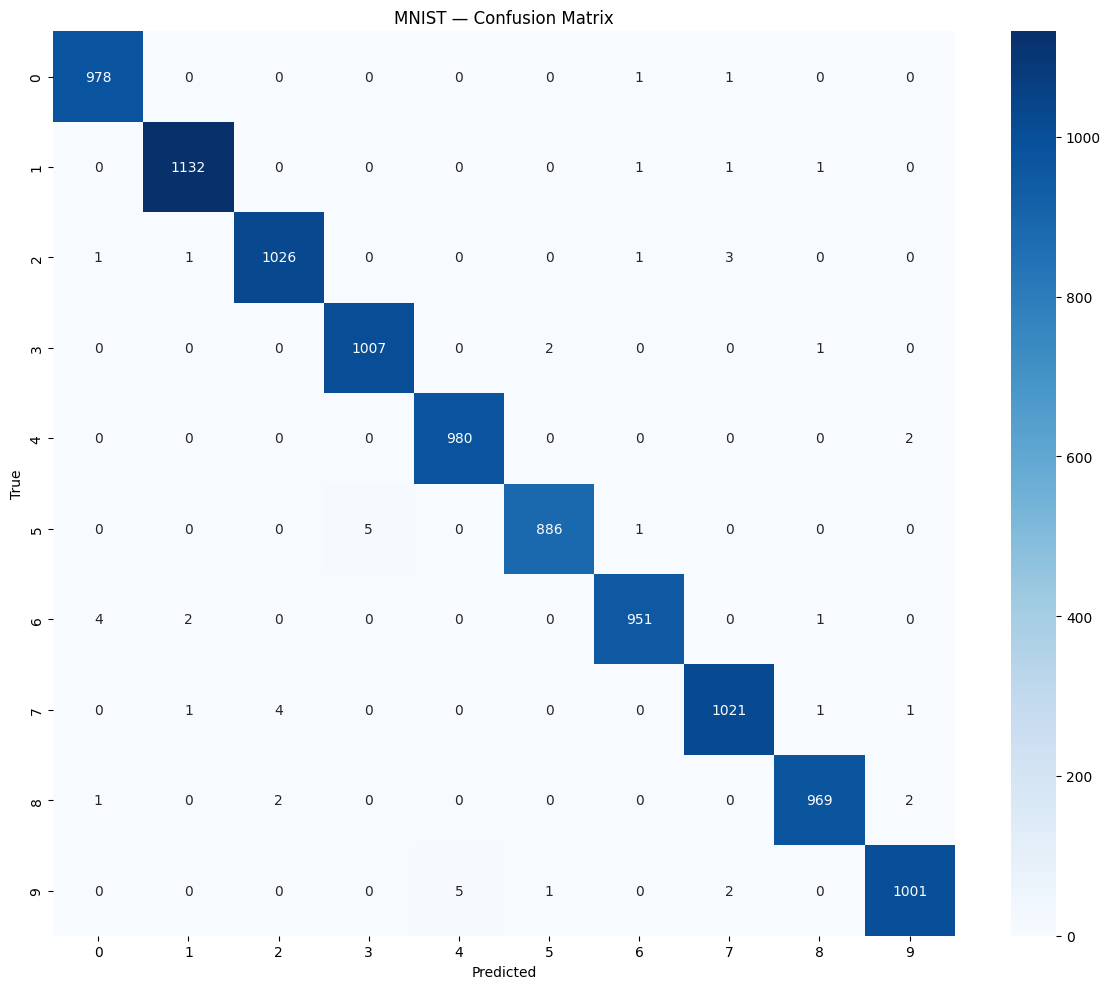


EMNIST Letters — Test Accuracy: 0.9530 | Loss: 0.1358

              precision    recall  f1-score   support

           A       0.96      0.97      0.97       800
           B       0.98      0.99      0.98       800
           C       0.98      0.98      0.98       800
           D       0.97      0.97      0.97       800
           E       0.98      0.99      0.98       800
           F       0.99      0.98      0.98       800
           G       0.94      0.83      0.88       800
           H       0.97      0.97      0.97       800
           I       0.78      0.70      0.74       800
           J       0.97      0.96      0.96       800
           K       0.98      0.99      0.99       800
           L       0.75      0.81      0.78       800
           M       0.98      1.00      0.99       800
           N       0.97      0.96      0.97       800
           O       0.98      0.96      0.97       800
           P       0.99      0.99      0.99       800
           Q       0.85  

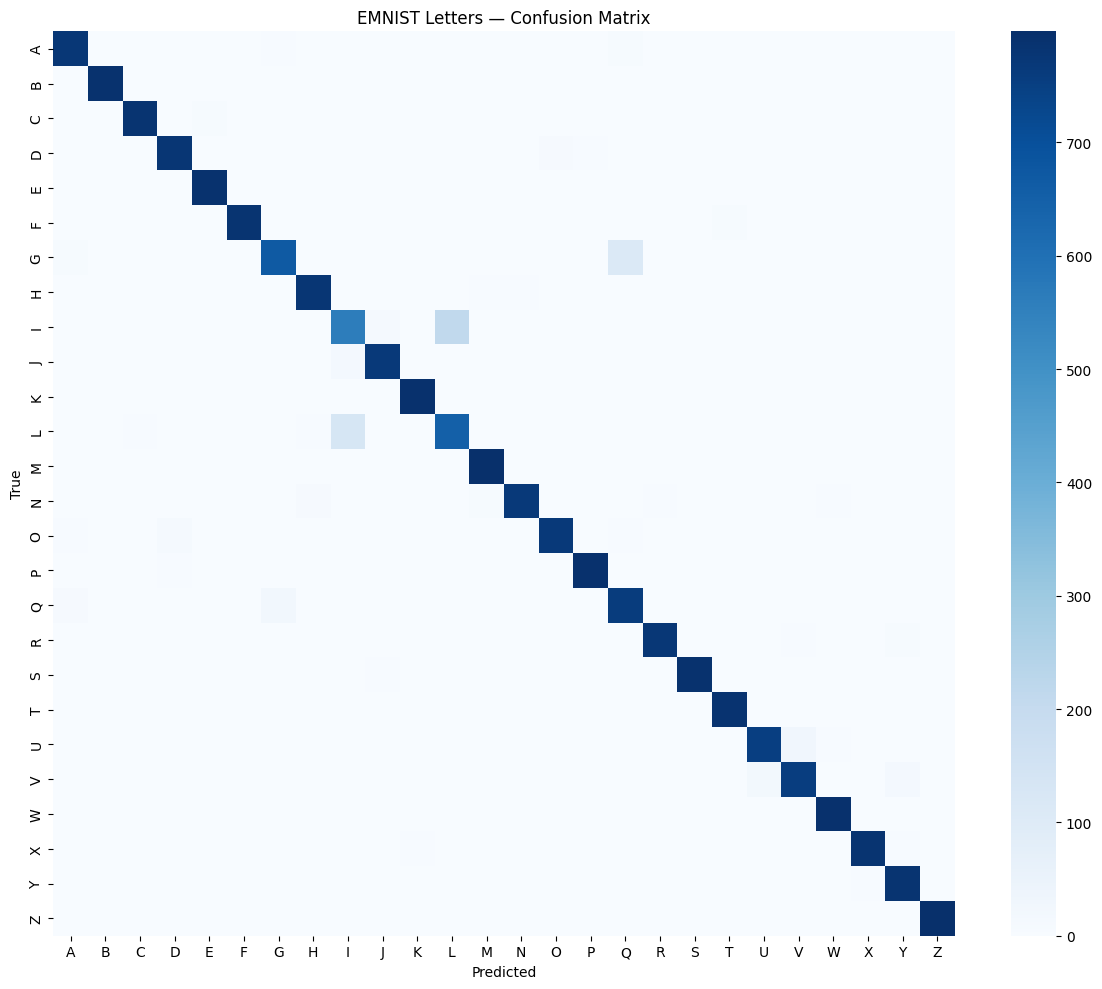

In [8]:
def evaluate_model(model, X_test, y_test, y_test_cat, class_names, title):
    loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f'\n{title} — Test Accuracy: {acc:.4f} | Loss: {loss:.4f}\n')

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)

    print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_names]))

    y_bin = label_binarize(y_test, classes=list(range(len(class_names))))
    roc   = roc_auc_score(y_bin, y_pred_prob, multi_class='ovr', average='macro')
    print(f'ROC-AUC (macro): {roc:.4f}\n')

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=len(class_names)<=10, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title} — Confusion Matrix')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

evaluate_model(mnist_model,  X_test_m, y_test_m, y_test_m_cat, list(range(10)), 'MNIST')
evaluate_model(emnist_model, X_test_e, y_test_e, y_test_e_cat, LETTERS,         'EMNIST Letters')

## 8. Misclassified Samples

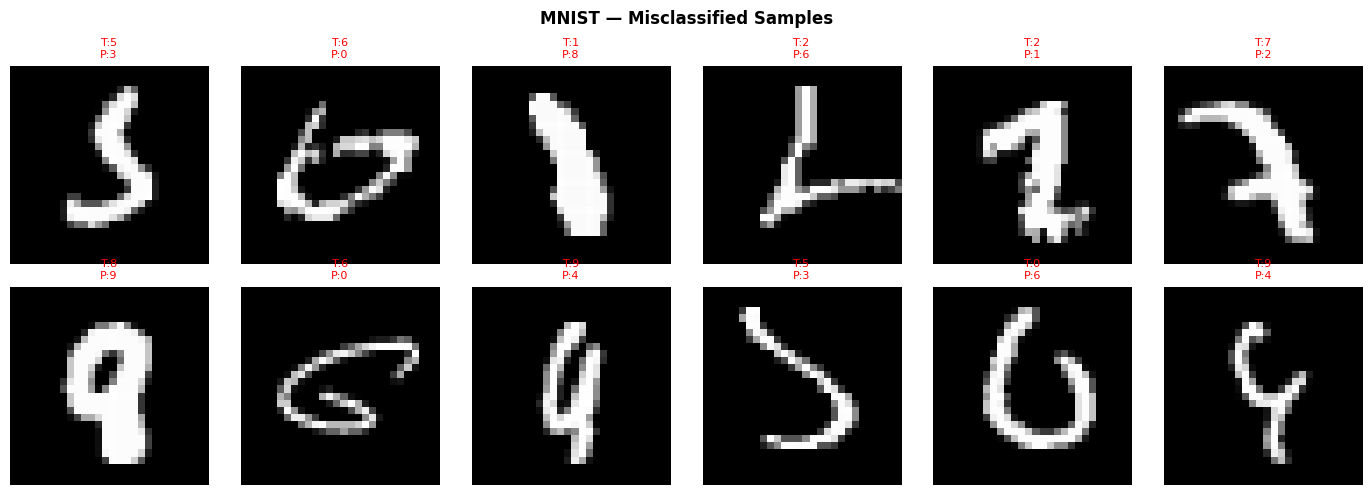

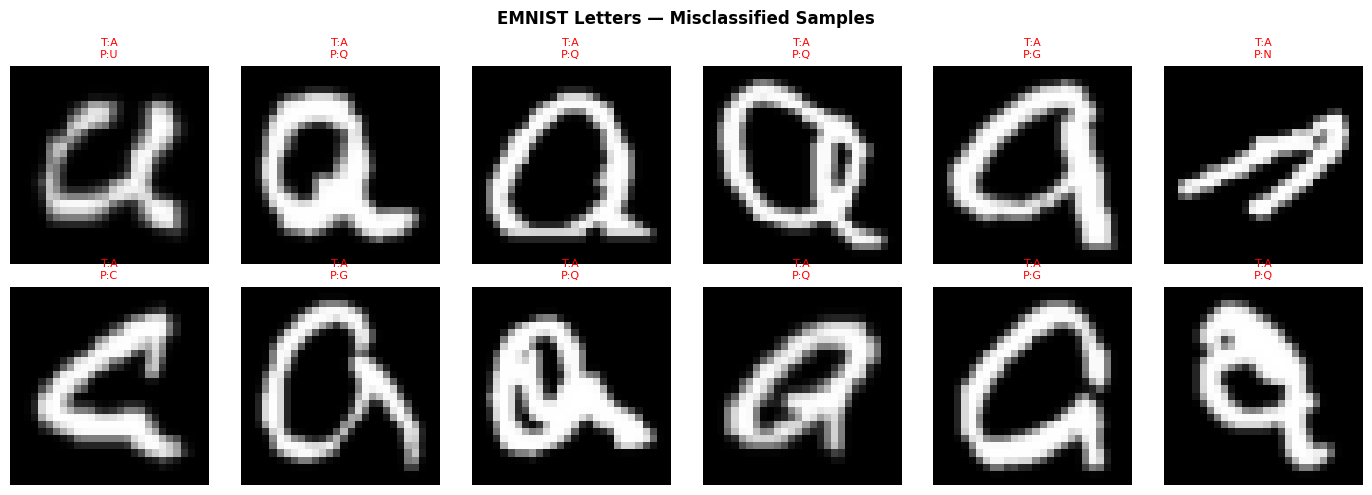

In [9]:
def show_errors(model, X_test, y_test, class_names, title, n=12):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    wrong  = np.where(y_pred != y_test)[0][:n]
    if len(wrong) == 0:
        print(f'{title}: No misclassifications found!')
        return
    fig, axes = plt.subplots(2, 6, figsize=(14, 5))
    for i, idx in enumerate(wrong[:12]):
        ax = axes[i // 6, i % 6]
        ax.imshow(X_test[idx].squeeze(), cmap='gray')
        ax.set_title(f'T:{class_names[y_test[idx]]}\nP:{class_names[y_pred[idx]]}',
                     color='red', fontsize=8)
        ax.axis('off')
    plt.suptitle(f'{title} — Misclassified Samples', fontweight='bold')
    plt.tight_layout(); plt.show()

show_errors(mnist_model,  X_test_m, y_test_m, [str(i) for i in range(10)], 'MNIST')
show_errors(emnist_model, X_test_e, y_test_e, LETTERS,                      'EMNIST Letters')

## 9. Save Models

In [10]:
mnist_model.save('mnist_cnn.keras')
emnist_model.save('emnist_cnn.keras')

m_acc = mnist_model.evaluate(X_test_m,  y_test_m_cat,  verbose=0)[1]
e_acc = emnist_model.evaluate(X_test_e, y_test_e_cat,  verbose=0)[1]

print('=' * 45)
print(f'  MNIST  Test Accuracy : {m_acc*100:.2f}%')
print(f'  EMNIST Test Accuracy : {e_acc*100:.2f}%')
print('  Models saved: mnist_cnn.keras & emnist_cnn.keras')
print('  Launch dashboard: streamlit run app.py')
print('=' * 45)

  MNIST  Test Accuracy : 99.51%
  EMNIST Test Accuracy : 95.30%
  Models saved: mnist_cnn.keras & emnist_cnn.keras
  Launch dashboard: streamlit run app.py
